# Linear Regression in Python

This notebook reads employee salary and years-of-experience data from `regression_data.csv`, fits a simple linear regression model with **Salary** as the outcome and **YearsExperience** as the predictor, reports model statistics, and plots the data with the fitted regression line.

## Load libraries

Import the packages used to read the CSV file, fit the regression model, and create the plot.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

## Load the data

Read `regression_data.csv` from the same folder as this notebook into a pandas DataFrame.

In [2]:
data = pd.read_csv("regression_data.csv")
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


## Fit the linear regression model

Fit **Salary ~ YearsExperience** using ordinary least squares (OLS) linear regression.

In [3]:
model = smf.ols("Salary ~ YearsExperience", data=data).fit()

## Model statistics

Print the coefficient of determination (R²) and p-values for the intercept and predictor. The slope-intercept formula and R² are also displayed at the top of the figure.

In [4]:
print(f"R-squared: {model.rsquared:.4f}")
print(f"p-value (Intercept): {model.pvalues['Intercept']:.4e}")
print(f"p-value (YearsExperience): {model.pvalues['YearsExperience']:.4e}")

R-squared: 0.7852
p-value (Intercept): 9.8450e-05
p-value (YearsExperience): 6.4065e-04


## Scatter plot with fitted regression line

Plot the observed data as a scatter plot and overlay the fitted regression line. The title and axis labels use the outcome and predictor variable names.

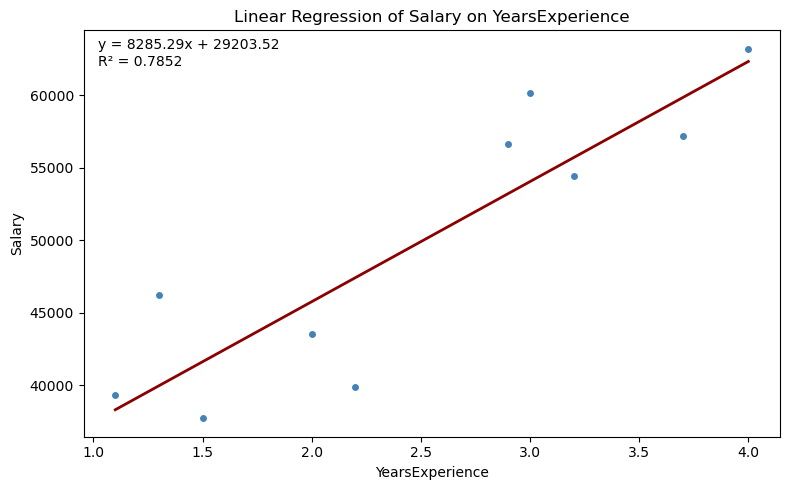

In [5]:
x_line = data["YearsExperience"]
y_line = model.predict(data)

intercept = model.params["Intercept"]
slope = model.params["YearsExperience"]
formula_text = f"y = {slope:.2f}x + {intercept:.2f}"
r2_text = f"R² = {model.rsquared:.4f}"

plt.figure(figsize=(8, 5))
plt.scatter(data["YearsExperience"], data["Salary"], color="steelblue", edgecolor="white")
plt.plot(x_line, y_line, color="darkred", linewidth=2)
plt.title("Linear Regression of Salary on YearsExperience")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.text(
    0.02,
    0.98,
    f"{formula_text}\n{r2_text}",
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    fontsize=10,
)
plt.tight_layout()
plt.show()